# Planning course graded exercice #1

In this notebook we will consider a probabilistic maze problem defined as a Markov Decision Process [scikit-decide](https://github.com/airbus/scikit-decide) domain, where the controlled agent moving in the maze can magically teleport itself upon some events.
You will then solve the problem by using one of the probabilistic algorithms provided by `scikit-decide`.

First we need to select the right planning class in `scikit-decide`'s [domain class generator](https://airbus.github.io/scikit-decide/codegen/), i.e. `MDPDomain` which is additionnally `renderable` and have `goals`.
It will generate the following domain class template:

In [1]:
from enum import Enum
from typing import *

from skdecide import *
from skdecide.builders.domain import *


# Example of State type (adapt to your needs)
class State(NamedTuple):
    x: int
    y: int


# Example of Action type (adapt to your needs)
class Action(Enum):
    up = 0
    down = 1
    left = 2
    right = 3


class D(MDPDomain, Renderable):
    T_state = State  # Type of states
    T_observation = T_state  # Type of observations
    T_event = Action  # Type of events
    T_value = float  # Type of transition values (rewards or costs)
    T_info = None  # Type of additional information in environment outcome


class MyDomain(D):
    
    def _is_terminal(self, state: D.T_state) -> D.T_predicate:
        pass
    
    def _get_transition_value(self, memory: D.T_state, action: D.T_event, next_state: Optional[D.T_state] = None) -> Value[D.T_value]:
        pass
    
    def _get_next_state_distribution(self, memory: D.T_state, action: D.T_event) -> SingleValueDistribution[D.T_state]:
        pass
    
    def _get_action_space_(self) -> Space[D.T_event]:
        pass
    
    def _get_applicable_actions_from(self, memory: D.T_state) -> Space[D.T_event]:
        pass
    
    def _get_goals_(self) -> Space[D.T_observation]:
        pass
    
    def _get_initial_state_(self) -> D.T_state:
        pass
    
    def _get_observation_space_(self) -> Space[D.T_observation]:
        pass
    
    def _render_from(self, memory: D.T_state, **kwargs: Any) -> Any:
        pass

Now, we implement a `TeleportationMazeDomain` class from this template.
We assume that whenever the agent attempts to go up, it will go back to its initial state with probability 0.9.
Every move costs 10 but 20 when we hit a wall or 1 when the agent goes through a "dollar" light green cell.
Therefore, the agent must find a compromise between going up in the middle of the maze to gather the dollars and not being teleported to the initial state.

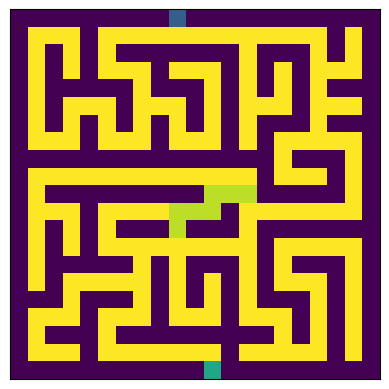

In [2]:
from enum import Enum
from typing import *
from copy import deepcopy

from skdecide import *
from skdecide.builders.domain import *
from skdecide.hub.space.gym import EnumSpace, ListSpace

# %matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


DEFAULT_MAZE = """
+-+-+-+-+o+-+-+-+-+-+
|   |             | |
+ + + +-+-+-+ +-+ + +
| | |   |   | | |   |
+ +-+-+ +-+ + + + +-+
| |   |   | |   |   |
+ + + + + + + +-+ +-+
|   |   |   | |     |
+-+-+-+-+-+-+-+ +-+ +
|             |   | |
+ +-+-+-+-+$$$+-+-+ +
|   |    $$$|       |
+ + + +-+$+-+ +-+-+-+
| | |         |     |
+ +-+-+ + +-+ + +-+ +
| |     | | | |   | |
+-+ +-+ + + + +-+ + +
|   |   |   |   | | |
+ +-+ +-+-+-+-+ + + +
|   |       |     | |
+-+-+-+-+-+x+-+-+-+-+
"""


# Example of State type (adapt to your needs)
class State(NamedTuple):
    x: int
    y: int


# Example of Action type (adapt to your needs)
class Action(Enum):
    up = 0
    down = 1
    left = 2
    right = 3


class D(MDPDomain, Goals, Renderable):
    T_state = State  # Type of states
    T_observation = T_state  # Type of observations
    T_event = Action  # Type of events
    T_value = float  # Type of transition values (rewards or costs)
    T_info = None  # Type of additional information in environment outcome


class TeleportationMazeDomain(D):
    
    def __init__(self, maze_str: str = DEFAULT_MAZE, dollar_cost=1.0, dollar_probability=0.9):
        maze = []
        self._dollars = []
        for y, line in enumerate(maze_str.strip().split("\n")):
            line = line.rstrip()
            row = []
            for x, c in enumerate(line):
                if c in {" ", "o", "x", "$"}:
                    row.append(1)  # spaces are 1s
                    if c == "o":
                        self._start = State(x, y)
                    if c == "x":
                        self._goal = State(x, y)
                    if c == "$":
                        self._dollars.append(State(x, y))
                else:
                    row.append(0)  # walls are 0s
            maze.append(row)
        # self._render_maze = deepcopy(self._maze)
        self._maze = maze
        self._num_cols = len(maze[0])
        self._num_rows = len(maze)
        self._dollar_cost = dollar_cost
        self._dollar_probability = dollar_probability
        self._ax = None
        self._fig = None
        self._image = None
    
    def _is_terminal(self, state: D.T_state) -> D.T_predicate:
        return state == self._goal
    
    def _get_transition_value(self, memory: D.T_state, action: D.T_event, next_state: Optional[D.T_state] = None) -> Value[D.T_value]:
        # If next state is a dollar, then the cost of moving there is the dollar cost with the specified probability, and 1.0 otherwise
        if next_state in self._dollars:
            return Value(cost=self._dollar_cost)
        # Otherwise, the cost of moving to a normal square is 1.0
        return Value(cost=1.0)
    
    def _get_next_state_distribution(self, memory: D.T_state, action: D.T_event) -> DiscreteDistribution[D.T_state]:
        # Calculate the next state based on the action taken
        if action == Action.up:
            next_s = State(memory.x, memory.y - 1)
        elif action == Action.down:
            next_s = State(memory.x, memory.y + 1)
        elif action == Action.left:
            next_s = State(memory.x - 1, memory.y)
        elif action == Action.right:
            next_s = State(memory.x + 1, memory.y)
        else:
            next_s = memory

        # If the destination square is special ($), there is a probability of success or staying in place
        if next_s in self._dollars:
            return DiscreteDistribution([
                (next_s, self._dollar_probability), 
                (memory, 1.0 - self._dollar_probability)
            ])
        
        # If it's a normal square, the movement is deterministic (probability 1.0)
        return DiscreteDistribution([(next_s, 1.0)])
    
    def _get_action_space_(self) -> Space[D.T_event]:
        return EnumSpace(Action)
    
    def _get_applicable_actions_from(self, memory: D.T_state) -> Space[D.T_event]:
        if memory == self._goal:
            return ListSpace([Action.down])
        transitions = [
            (Action.left, State(memory.x - 1, memory.y)),
            (Action.right, State(memory.x + 1, memory.y)),
            (Action.up, State(memory.x, memory.y - 1)),
            (Action.down, State(memory.x, memory.y + 1))
        ]
        applicable_actions = []
        for tr in transitions:
            if (
                0 <= tr[1].x < self._num_cols
                and 0 <= tr[1].y < self._num_rows
                and self._maze[tr[1].y][tr[1].x] == 1
            ):
                applicable_actions.append(tr[0])
        assert len(applicable_actions) > 0
        return ListSpace(applicable_actions)
    
    def _get_goals_(self) -> Space[D.T_observation]:
        return ListSpace([self._goal])
    
    def _get_initial_state_(self) -> D.T_state:
        return self._start
    
    def _get_observation_space_(self) -> Space[D.T_observation]:
        pass
    
    def _render_from(self, memory: D.T_state, **kwargs: Any) -> Any:
        if self._ax is None:
            fig, ax = plt.subplots(1)
            #fig.canvas.set_window_title("Maze")
            ax.set_aspect("equal")  # set the x and y axes to the same scale
            plt.xticks([])  # remove the tick marks by setting to an empty list
            plt.yticks([])  # remove the tick marks by setting to an empty list
            ax.invert_yaxis()  # invert the y-axis so the first row of data is at the top
            self._ax = ax
            self._fig = fig
            plt.ion()
        maze = deepcopy(self._maze)
        for d in self._dollars:
            maze[d.y][d.x] = 0.9
        maze[self._goal.y][self._goal.x] = 0.6
        maze[memory.y][memory.x] = 0.3
        if 'path' in kwargs:
            for s in kwargs.get('path'):
                maze[s.y][s.x] = 0.5
        if self._image is None:
            self._image = self._ax.imshow(maze)
        else:
            self._image.set_data(maze)
        display(self._fig)
        clear_output(wait = True)
        plt.pause(0.001)
        
maze = TeleportationMazeDomain()
maze.render(maze._get_initial_state_())

Now, we solve the domain with the LRTDP solver, which is a famous extension of the LRTA* solver to solve Stochastic Shortest Path problems.

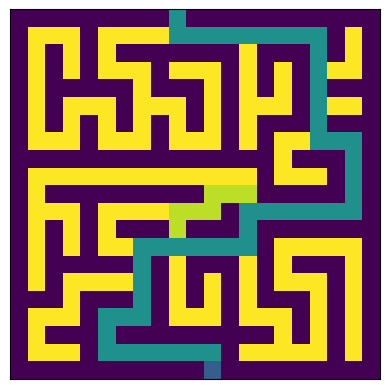

In [3]:
from skdecide.hub.solver.lrtdp import LRTDP
from skdecide.utils import rollout

from math import sqrt

domain_factory = lambda: TeleportationMazeDomain(maze_str=DEFAULT_MAZE, dollar_cost=1.0, dollar_probability=0.9)

solver_factory = lambda: LRTDP(
    domain_factory=domain_factory,
    heuristic=lambda d, s: Value(cost=sqrt((d._goal.x - s.x)**2 + (d._goal.y - s.y)**2)),
    discount=1.0,
    epsilon=0.001,
    parallel=False,
    verbose=False,
)

with solver_factory() as solver:
    solver.solve()
    
    plan = []
    cost = 0
    evaluation_domain = domain_factory()
    observation = evaluation_domain.reset()
    path = [observation]
    nb_steps = 0
    while (not evaluation_domain.is_goal(observation)) and nb_steps < 1000:
        plan.append(solver.sample_action(observation))
        outcome = evaluation_domain.step(plan[-1])
        cost += outcome.value.cost
        observation = outcome.observation
        path.append(observation)
        nb_steps += 1
        
    print(f'Found a plan of cost {cost}: {plan}')
    for i, s in enumerate(path):
        evaluation_domain.render(s, path=path[:i])

Now play with different `dollar_cost` and `dollar_probability` until finding a path that goes through the dollars in the maze.
Please comment your findings.

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Define parameters for the comparison
dollar_costs = [0.1, 0.5, 1.0] #Error with more than 3 values
dollar_probabilities = [0.1, 0.5, 0.8, 1.0]
results = []

# Calculate the total number of iterations for the progress bar
total_iterations = len(dollar_costs) * len(dollar_probabilities)

print(f"Starting experiment: {total_iterations} configurations to test.\n")

with tqdm(total=total_iterations, desc="Optimizing Paths") as pbar:
    for cost in dollar_costs:
        for prob in dollar_probabilities:
            
            # Definition of the domain
            curr_domain_factory = lambda c=cost, p=prob: TeleportationMazeDomain(
                maze_str=DEFAULT_MAZE, dollar_cost=c, dollar_probability=p
            )
            
            # Solver configuration
            with LRTDP(domain_factory=curr_domain_factory,
                       heuristic=lambda d, s: Value(cost=sqrt((d._goal.x - s.x)**2 + (d._goal.y - s.y)**2)),
                       discount=1.0, epsilon=0.001) as solver:
                
                solver.solve()
                
                # --- CONTROLLED EVALUATION ---
                domain = curr_domain_factory()
                obs = domain.reset()
                steps = 0
                used_dollars = False
                max_steps = 150 
                
                while not domain.is_goal(obs) and steps < max_steps:
                    action = solver.sample_action(obs)
                    
                    # Calculate the next observation based on the action taken (deterministic for evaluation)
                    if action == Action.up: next_obs = State(obs.x, obs.y - 1)
                    elif action == Action.down: next_obs = State(obs.x, obs.y + 1)
                    elif action == Action.left: next_obs = State(obs.x - 1, obs.y)
                    elif action == Action.right: next_obs = State(obs.x + 1, obs.y)
                    else: next_obs = obs
                    
                    if next_obs in domain._dollars:
                        used_dollars = True
                    
                    obs = next_obs
                    steps += 1
                
                # Log results for this configuration
                if used_dollars:
                    tqdm.write(f" -> Found path using dollars at Cost:{cost}, Prob:{prob}")
                
                results.append({
                    "Cost ($)": cost,
                    "Prob ($)": prob,
                    "Steps": steps,
                    "Used Dollars?": used_dollars,
                    "Reached Goal": obs == domain._goal
                })
            
            pbar.update(1)

Starting experiment: 12 configurations to test.



Optimizing Paths: 100%|██████████| 12/12 [00:00<00:00, 127.14it/s]

[2026-04-15 22:17:37.242] [info] Running sequential LRTDP solver from state State(x=9, y=0)
[2026-04-15 22:17:37.246] [info] LRTDP finished to solve from state State(x=9, y=0) in 3e-06 seconds with 31 rollouts and visited 204 states. 
[2026-04-15 22:17:37.247] [info] Running sequential LRTDP solver from state State(x=9, y=0)
[2026-04-15 22:17:37.247] [info] LRTDP finished to solve from state State(x=9, y=0) [solved state]
[2026-04-15 22:17:37.247] [info] Running sequential LRTDP solver from state State(x=9, y=1)
[2026-04-15 22:17:37.247] [info] LRTDP finished to solve from state State(x=9, y=1) [solved state]
[2026-04-15 22:17:37.247] [info] Running sequential LRTDP solver from state State(x=10, y=1)
[2026-04-15 22:17:37.247] [info] LRTDP finished to solve from state State(x=10, y=1) [solved state]
[2026-04-15 22:17:37.247] [info] Running sequential LRTDP solver from state State(x=11, y=1)
[2026-04-15 22:17:37.247] [info] LRTDP finished to solve from state State(x=11, y=1) [solved stat

 [info] Running sequential LRTDP solver from state State(x=13, y=10)
[2026-04-15 22:17:37.305] [info] LRTDP finished to solve from state State(x=13, y=10) [solved state]
[2026-04-15 22:17:37.305] [info] Running sequential LRTDP solver from state State(x=12, y=10)
[2026-04-15 22:17:37.305] [info] LRTDP finished to solve from state State(x=12, y=10) [solved state]
[2026-04-15 22:17:37.305] [info] Running sequential LRTDP solver from state State(x=11, y=10)
[2026-04-15 22:17:37.305] [info] LRTDP finished to solve from state State(x=11, y=10) [solved state]
[2026-04-15 22:17:37.305] [info] Running sequential LRTDP solver from state State(x=11, y=11)
[2026-04-15 22:17:37.305] [info] LRTDP finished to solve from state State(x=11, y=11) [solved state]
[2026-04-15 22:17:37.305] [info] Running sequential LRTDP solver from state State(x=10, y=11)
[2026-04-15 22:17:37.305] [info] LRTDP finished to solve from state State(x=10, y=11) [solved state]
[2026-04-15 22:17:37.305] [info] Running sequentia

lver from state State(x=18, y=7)
[2026-04-15 22:17:37.315] [info] LRTDP finished to solve from state State(x=18, y=7) [solved state]
[2026-04-15 22:17:37.315] [info] Running sequential LRTDP solver from state State(x=19, y=7)
[2026-04-15 22:17:37.315] [info] LRTDP finished to solve from state State(x=19, y=7) [solved state]
[2026-04-15 22:17:37.315] [info] Running sequential LRTDP solver from state State(x=19, y=8)
[2026-04-15 22:17:37.315] [info] LRTDP finished to solve from state State(x=19, y=8) [solved state]
[2026-04-15 22:17:37.315] [info] Running sequential LRTDP solver from state State(x=19, y=9)
[2026-04-15 22:17:37.315] [info] LRTDP finished to solve from state State(x=19, y=9) [solved state]
[2026-04-15 22:17:37.315] [info] Running sequential LRTDP solver from state State(x=19, y=10)
[2026-04-15 22:17:37.315] [info] LRTDP finished to solve from state State(x=19, y=10) [solved state]
[2026-04-15 22:17:37.315] [info] Running sequential LRTDP solver from state State(x=19, y=11)

In [7]:
# Show final results in a DataFrame
df = pd.DataFrame(results)
print("\n" + "="*30)
print("FINAL COMPARISON TABLE")
print("="*30)
print(df.to_string(index=False))


FINAL COMPARISON TABLE
 Cost ($)  Prob ($)  Steps  Used Dollars?  Reached Goal
      0.1       0.1     50          False          True
      0.1       0.5     52           True          True
      0.1       0.8     52           True          True
      0.1       1.0     52           True          True
      0.5       0.1     50          False          True
      0.5       0.5     50          False          True
      0.5       0.8     52           True          True
      0.5       1.0     52           True          True
      1.0       0.1     50          False          True
      1.0       0.5     50          False          True
      1.0       0.8     50          False          True
      1.0       1.0     50          False          True


## 📊 Analysis of Pathfinding Behavior: Risk vs. Reward

Based on the experimental results, we can observe how the agent's decision-making process changes according to the `dollar_cost` and `dollar_probability`. The agent must choose between a **safe, longer path** (1.0 cost per step) and a **risky "shortcut"** (the dollar cells).

### 1. The Threshold of "Greed"
* **Low Cost ($0.1$):** When the cost is very low, the agent is willing to take the shortcut even with a **50% success probability**. However, at **10% probability ($0.1$)**, the agent prefers the safe route. This is because the *expected cost* of trying to enter the dollar cell multiple times outweighs the benefit of the shortcut.
* **Medium Cost ($0.5$):** At this price point, the agent becomes more conservative. It only takes the shortcut if the probability of success is **high (80% or 100%)**. At 50% probability, it now prefers the standard path, showing that the increased cost reduces its tolerance for risk.
* **High Cost ($1.0$):** When the cost of the dollar cell equals the cost of a normal cell, the agent **completely ignores the dollars**. This happens regardless of the probability ($100\%$ or $10\%$). This suggests that the dollar cells in this maze layout do not offer a shorter path in terms of distance, only in terms of cost (if they were cheaper).

### 2. Key Findings: Expected Value ($EV$)
The solver effectively calculates the **Expected Cost** to reach the goal. The decision to use a dollar cell $S_d$ follows a logic similar to:
$$Cost(Safe\ Path) < \frac{Cost(\$)}{Prob(\$)} + Cost(Remaining\ Path)$$

| Scenario | Cost ($) | Prob ($) | Decision | Reason |
| :--- | :--- | :--- | :--- | :--- |
| **High Risk** | 0.1 | 0.1 | ❌ Avoid | Expected attempts (10) make it too "expensive". |
| **Balanced** | 0.1 | 0.5 | ✅ Use | The shortcut is cheap enough to justify mid-risk. |
| **Conservative**| 0.5 | 0.5 | ❌ Avoid | Cost increases, making the risk-to-reward ratio poor. |
| **Neutral** | 1.0 | 1.0 | ❌ Avoid | No financial incentive to deviate from the standard path. |

### 3. Conclusion
The agent acts as a **rational economic actor**. It only "teleports" through dollars when the cost-probability ratio is significantly better than the deterministic cost of the standard path. In this specific maze, the dollars act as **incentives** that only work when they are heavily subsidized (low cost) or extremely reliable (high probability).